# Phase 6 — Machine Learning Modeling and Forecasting

This phase focuses on building and evaluating machine learning models for retail sales forecasting.

The objective is to predict future weekly sales using the engineered forecasting features created during the previous phase.

The modeling phase includes:

* linear models
* tree-based ensemble models
* Prophet forecasting

Different preprocessing approaches will also be compared to evaluate their impact on forecasting performance, including:

* scaled vs unscaled features
* original vs transformed target variables

The models will be evaluated using chronological forecasting data to simulate real-world future prediction scenarios while preventing data leakage.

Performance comparison will be based on forecasting evaluation metrics such as:

* MAE
* RMSE
* R² Score

The final goal is to identify the most effective forecasting approach for predicting retail sales behavior while also understanding the influence of preprocessing techniques and feature engineering on model performance.


In [ ]:
# data handling
import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# linear models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

# tree-based models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)

# boosting models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# model evaluation
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error
)

# hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

#preprocessing
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline

# import prophet
from prophet import Prophet

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# load processe data
X_train = pd.read_csv('/home/emeka/projects/ML_Portfolio/retail-sales-forecasting/data/processed/X_train_unscaled.csv')
X_test = pd.read_csv('/home/emeka/projects/ML_Portfolio/retail-sales-forecasting/data/processed/X_test_unscaled.csv')

X_train_scaled = pd.read_csv('/home/emeka/projects/ML_Portfolio/retail-sales-forecasting/data/processed/X_train_scaled.csv')
X_test_scaled = pd.read_csv('/home/emeka/projects/ML_Portfolio/retail-sales-forecasting/data/processed/X_test_scaled.csv')

y_train = pd.read_csv('/home/emeka/projects/ML_Portfolio/retail-sales-forecasting/data/processed/y_train_unscaled.csv')
y_test = pd.read_csv('/home/emeka/projects/ML_Portfolio/retail-sales-forecasting/data/processed/y_test_unscaled.csv')

y_train_log = pd.read_csv('/home/emeka/projects/ML_Portfolio/retail-sales-forecasting/data/processed/y_train_log.csv')
y_test_log = pd.read_csv('/home/emeka/projects/ML_Portfolio/retail-sales-forecasting/data/processed/y_test_log.csv')

In [ ]:
# convert dataframe to series on target
y_train = y_train.squeeze()
y_test = y_test.squeeze()

y_train_log = y_train_log.squeeze()
y_test_log = y_test_log.squeeze()

In [ ]:
# inspect dataset shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_train_log shape: {y_train_log.shape}")
print(f"y_test_log shape: {y_test_log.shape}")

X_train shape: (268488, 27)
X_test shape: (127116, 27)
y_train shape: (268488,)
y_test shape: (127116,)
X_train_scaled shape: (268488, 27)
X_test_scaled shape: (127116, 27)
y_train_log shape: (268488,)
y_test_log shape: (127116,)


## Baseline Forecast Model

In this section, a baseline forecasting model will be created to establish a minimum performance benchmark for the forecasting task.

A naive forecasting approach will be used where the previous week's sales (`Lag_1`) are used to predict the current week's sales.

This baseline model will serve as a reference point for evaluating whether more advanced machine learning models are able to improve forecasting performance.


In [ ]:
# create baseline predictions using previous week's sales
baseline_pred = X_test['Lag_1']

#  calculate baseline evaluation metrics
baseline_mae = mean_absolute_error(y_test, baseline_pred)

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

baseline_r2 = r2_score(y_test, baseline_pred)

# display baseline results
print(f'Baseline MAE: {baseline_mae:.2f}')
print(f'Baseline RMSE: {baseline_rmse:.2f}')
print(f'Baseline R²: {baseline_r2:.4f}')

Baseline MAE: 1720.87
Baseline RMSE: 3945.25
Baseline R²: 0.9682


## Baseline Model Results

The baseline forecasting model produced strong performance using the previous week's sales (`Lag_1`) as the prediction for the current week's sales.

### Baseline Performance

* MAE: 1720.87
* RMSE: 3945.25
* R² Score: 0.9682

The high R² score indicates that weekly sales show strong temporal dependency, meaning recent sales behavior is highly predictive of future sales.

The relatively low forecasting errors suggest that sales patterns remain fairly consistent across consecutive weeks, although larger errors still occur during periods of higher sales volatility such as holidays and promotional periods.

These results establish a strong forecasting benchmark for evaluating the performance of the advanced machine learning models.


## Automated Modeling Framework

Before training the machine learning models, an automated modeling framework will be developed to streamline the experimentation process.

The framework will be designed to:

* train multiple models automatically
* generate predictions
* evaluate forecasting performance
* store model evaluation metrics
* support preprocessing comparisons

This approach will improve workflow consistency, reduce repetitive code, and allow fair comparison across different forecasting models and preprocessing strategies.


In [ ]:
import joblib

# load fitted transformer
power_transformer = joblib.load('../model/power_transformer.pkl')

In [ ]:
# function to train and evaluate forecasting models
def run_models(
    models,
    X_train,
    y_train,
    X_test,
    y_test,
    feature_type,
    target_type,
    inverse_transformer=None
):
    """
    Train multiple forecasting models,
    generate predictions,
    evaluate performance,
    and return model results.
    """

    # store experiment results
    results = []

    # loop through models
    for model_name, model in models.items():

        # train model
        model.fit(X_train, y_train)

        # generate predictions
        predictions = model.predict(X_test)

        # inverse transform predictions if needed
        if inverse_transformer is not None:

            predictions = inverse_transformer.inverse_transform( predictions.reshape(-1, 1)).flatten()

            y_actual = inverse_transformer.inverse_transform(y_test.values.reshape(-1, 1)).flatten()

        else:
            y_actual = y_test

        # calculate evaluation metrics
        mae = mean_absolute_error(y_actual, predictions)

        rmse = np.sqrt(mean_squared_error(y_actual, predictions))

        r2 = r2_score(y_actual, predictions)

        # store results
        results.append({

            'Model': model_name,
            'Feature_Type': feature_type,
            'Target_Type': target_type,
            'MAE': mae,
            'RMSE': rmse,
            'R2_Score': r2
        })

        # display progress
        print(f'{model_name} completed')

    return results

## Linear Model Experiments

In this section, multiple linear regression models will be trained and evaluated using different preprocessing strategies.

The experiments will compare:

* unscaled features with original target values
* scaled features with original target values
* scaled features with transformed target values

The objective is to examine how feature scaling and target transformation influence forecasting performance in linear models.

The following models will be evaluated:

* Linear Regression
* Ridge Regression
* Lasso Regression
* Elastic Net Regression
## Linear Model Experiments

In this section, multiple linear regression models will be trained and evaluated using different preprocessing strategies.

The experiments will compare:

* unscaled features with original target values
* scaled features with original target values
* scaled features with transformed target values

The objective is to examine how feature scaling and target transformation influence forecasting performance in linear models.

The following models will be evaluated:

* Linear Regression
* Ridge Regression
* Lasso Regression
* Elastic Net Regression


In [ ]:
# linear regression models
linear_models = {
    'Linear Regression' : LinearRegression(),
    'Ridge Regression' : Ridge(),
    'Lasso Regression' : Lasso(),
    'ElasticNet' : ElasticNet()
}

## **Experiment 1: Unscaled Features + Original Target**

In [ ]:
# run linear models on unscaled features
linear_unscaled_result = run_models(
    models=linear_models,

    X_train=X_train,
    X_test=X_test,

    y_train=y_train,
    y_test=y_test,

    feature_type="Unscaled",
    target_type='Original'
)

Linear Regression completed
Ridge Regression completed
Lasso Regression completed
ElasticNet completed


## **Experiment 2: Scaled Features + Original Target**

In [ ]:
# run linear models on scaled features
linear_scaled_result = run_models(
    models=linear_models,

    X_train=X_train_scaled,
    X_test=X_test_scaled,

    y_train=y_train,
    y_test=y_test,

    feature_type="Scaled",
    target_type="Original"
)

Linear Regression completed
Ridge Regression completed
Lasso Regression completed
ElasticNet completed


## **Experiment 3: Scaled Features + Transformed Target**

In [ ]:
# run linear models on transformed target
linear_transformed_result = run_models(
    models=linear_models,

    X_train=X_train_scaled,
    X_test=X_test_scaled,

    y_train=y_train_log,
    y_test=y_test_log,

    feature_type="Scaled",
    target_type="Transformed",

    inverse_transformer=power_transformer
)

Linear Regression completed
Ridge Regression completed
Lasso Regression completed
ElasticNet completed


In [ ]:
# combine linear model results
linear_results = (linear_unscaled_result + linear_scaled_result + linear_transformed_result)

In [ ]:
# create linear model results dataframe
linear_results_df = pd.DataFrame(linear_results)

# display results
linear_results_df.sort_values(by='RMSE')

,Model,Feature_Type,Target_Type,MAE,RMSE,R2_Score
3,ElasticNet,Unscaled,Original,1971.115200,3982.030956,0.967635
6,Lasso Regression,Scaled,Original,2281.008215,4136.230868,0.965080
2,Lasso Regression,Unscaled,Original,2282.047937,4136.875723,0.965069
1,Ridge Regression,Unscaled,Original,2314.378960,4154.569101,0.964770
5,Ridge Regression,Scaled,Original,2314.403846,4154.572974,0.964770
0,Linear Regression,Unscaled,Original,2314.522998,4154.650207,0.964768
4,Linear Regression,Scaled,Original,2314.522998,4154.650207,0.964768
7,ElasticNet,Scaled,Original,2791.560122,4780.237778,0.953359
9,Ridge Regression,Scaled,Transformed,3582.004085,7290.605276,0.891510
8,Linear Regression,Scaled,Transformed,3582.022958,7290.671736,0.891508


## Linear Model Results and Observations

The linear models performed strongly on the original target variable across both scaled and unscaled feature configurations.

Feature scaling had little to no impact on model performance, as the evaluation metrics remained almost identical after scaling. This suggests that the engineered forecasting features were already within reasonable numerical ranges for the linear models.

The models trained on the original target variable consistently outperformed the transformed target experiments. Applying the Yeo-Johnson transformation reduced forecasting performance across all linear models, indicating that transforming the sales values may have weakened important temporal sales patterns contained in the original data.

Among the linear models, Elastic Net achieved the lowest RMSE on the original target experiment with an RMSE of 3982.03 and an R² score of 0.9676. Ridge Regression and standard Linear Regression also produced stable forecasting performance.

However, the naive baseline forecasting model still achieved the strongest overall performance with:

* RMSE: 3945.25
* MAE: 1720.87
* R² Score: 0.9682

This indicates that previous sales values contain extremely strong predictive information within the dataset, making the forecasting task highly dependent on recent historical sales behavior.


## Tree-Based Model Experiments

In this section, tree-based regression models will be trained and evaluated using the engineered forecasting features.

Unlike linear models, tree-based models are generally less sensitive to feature scaling because they split data based on feature thresholds rather than distance calculations.

The experiments will compare:

* unscaled features with original target values
* unscaled features with transformed target values

The objective is to examine whether tree-based models are able to capture nonlinear forecasting patterns more effectively than the linear regression models.

The following models will be evaluated:

* Decision Tree Regressor
* Random Forest Regressor


In [ ]:
# tree-based regression models
tree_models = {
    'Random Forest' : RandomForestRegressor(random_state=42),
    'Decision Tree' : DecisionTreeRegressor(random_state=42)
}

## **Experiment 1: Original Target Experiment**

In [ ]:
# run tree models on original target
tree_original_result = run_models(
    models=tree_models,

    X_train=X_train,
    X_test=X_test,

    y_train=y_train,
    y_test=y_test,

    feature_type='Unscaled',
    target_type="Original"
)

Random Forest completed
Decision Tree completed


## **Experiment 2: Transformed Target Experiment**

In [ ]:
# run tree models on transformed target
tree_transformed_results = run_models(
    models=tree_models,

    X_train=X_train,
    X_test=X_test,

    y_train=y_train_log,
    y_test=y_test_log,

    feature_type="Unscaled",
    target_type="Transformed",

    inverse_transformer=power_transformer

)

Random Forest completed
Decision Tree completed


In [ ]:
# combine tree model results
tree_results = (tree_original_result + tree_transformed_results)

# convert to dataframe
tree_results_df = pd.DataFrame(tree_results)

# # sort results by RMSE

tree_results_df.sort_values(by='RMSE')

,Model,Feature_Type,Target_Type,MAE,RMSE,R2_Score
2,Random Forest,Unscaled,Transformed,1530.035392,3256.624243,0.978353
0,Random Forest,Unscaled,Original,1569.363211,3329.240115,0.977377
3,Decision Tree,Unscaled,Transformed,2423.076844,5320.777203,0.942215
1,Decision Tree,Unscaled,Original,2525.278480,5927.824018,0.928278


## Tree-Based Model Results and Observations

The tree-based models produced stronger forecasting performance than the linear regression models, particularly when using the transformed target variable.

Random Forest achieved the best overall forecasting performance so far. The model trained on the transformed target variable produced:

* RMSE: 3256.62
* MAE: 1530.04
* R² Score: 0.9785

This outperformed both the naive baseline model and all linear regression experiments.

For comparison, the naive baseline model achieved:

* RMSE: 3945.25
* MAE: 1720.87
* R² Score: 0.9682

The results suggest that Random Forest was able to capture nonlinear forecasting patterns and feature interactions more effectively than the linear models.

Unlike the linear regression experiments, the Yeo-Johnson transformed target improved Random Forest performance. This indicates that the transformed sales distribution may have helped reduce the influence of extreme sales spikes while still preserving useful forecasting patterns for the ensemble model.

Decision Tree Regression performed significantly worse than Random Forest across both experiments. This suggests that a single decision tree struggled to generalize effectively and likely overfitted the training data, while the ensemble averaging mechanism in Random Forest improved forecasting stability and predictive accuracy.


## Boosting Model Experiments

In this section, boosting-based ensemble models will be trained and evaluated for retail sales forecasting.

Boosting models improve prediction performance by sequentially learning from previous model errors and focusing on difficult observations during training.

The experiments will compare:

* unscaled features with original target values
* unscaled features with transformed target values

The objective is to determine whether boosting algorithms can improve forecasting accuracy beyond the baseline model, linear regression models, and Random Forest.

The following models will be evaluated:

* AdaBoost Regressor
* Gradient Boosting Regressor
* XGBoost Regressor
* LightGBM Regressor
* CatBoost Regressor


In [ ]:
# boosting regression models
boosted_model = {
    'AdaBoost' : AdaBoostRegressor(random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'LightGBM' : LGBMRegressor(random_state=42),
    'CatBoost' : CatBoostRegressor(random_state=42)
}

## **Experiment 1: Original Target Experiment**

In [ ]:
# run boosting models on original target
boosting_original_result = run_models(
    models=boosted_model,

    X_train=X_train,
    X_test=X_test,

    y_train=y_train,
    y_test=y_test,

    feature_type='Unscaled',
    target_type='Original'
)

AdaBoost completed
Gradient Boosting completed
XGBoost completed
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.061286 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3536
[LightGBM] [Info] Number of data points in the train set: 268488, number of used features: 27
[LightGBM] [Info] Start training from score 16255.400373
LightGBM completed
Learning rate set to 0.099072
0:	learn: 21096.1794826	total: 135ms	remaining: 2m 14s
1:	learn: 19311.7462985	total: 173ms	remaining: 1m 26s
2:	learn: 17732.3902435	total: 215ms	remaining: 1m 11s
3:	learn: 16309.9028534	total: 252ms	remaining: 1m 2s
4:	learn: 15051.3831535	total: 296ms	remaining: 58.9s
5:	learn: 13940.9241793	total: 338ms	remaining: 56.1s
6:	learn: 12943.4053243	total: 377ms	remaining: 53.5s
7:	learn: 12065.7588242	total: 419ms	remaining: 51.9s
8:	learn: 11295.6914420	total: 455ms	remaining: 50.1s
9:	learn: 10609.9630635	total: 497ms	remaining: 49

## **Experiment 2: Transformed Target Experiment**

In [ ]:
# run boosting models on transformed target
boosting_transformed_result = run_models(
    models=boosted_model,


    X_train=X_train,
    X_test=X_test,

    y_train=y_train_log,
    y_test=y_test_log,

    feature_type='Unscaled',
    target_type='Transformed',

    inverse_transformer=power_transformer
)

AdaBoost completed
Gradient Boosting completed
XGBoost completed
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.059514 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3536
[LightGBM] [Info] Number of data points in the train set: 268488, number of used features: 27
[LightGBM] [Info] Start training from score 0.000000
LightGBM completed
Learning rate set to 0.099072
0:	learn: 0.9176287	total: 48.9ms	remaining: 48.9s
1:	learn: 0.8439146	total: 94.6ms	remaining: 47.2s
2:	learn: 0.7784059	total: 140ms	remaining: 46.5s
3:	learn: 0.7201009	total: 191ms	remaining: 47.6s
4:	learn: 0.6687500	total: 241ms	remaining: 48s
5:	learn: 0.6234576	total: 296ms	remaining: 49.1s
6:	learn: 0.5831523	total: 351ms	remaining: 49.9s
7:	learn: 0.5479256	total: 412ms	remaining: 51.1s
8:	learn: 0.5176250	total: 457ms	remaining: 50.3s
9:	learn: 0.4910486	total: 494ms	remaining: 48.9s
10:	learn: 0.4680856	total: 542ms	remaining

In [ ]:
# combine boosting model results
boosting_result = (boosting_original_result + boosting_transformed_result)

# create boosting model results dataframe
boosting_result_df = pd.DataFrame(boosting_result)

# sort results by RMSE
boosting_result_df.sort_values( by='RMSE')

,Model,Feature_Type,Target_Type,MAE,RMSE,R2_Score
9,CatBoost,Unscaled,Transformed,1469.164350,3164.261642,0.979563
4,CatBoost,Unscaled,Original,1525.223225,3210.412672,0.978963
3,LightGBM,Unscaled,Original,1513.247293,3282.181994,0.978012
8,LightGBM,Unscaled,Transformed,1489.306673,3306.947909,0.977679
7,XGBoost,Unscaled,Transformed,1590.864724,3430.843062,0.975975
6,Gradient Boosting,Unscaled,Transformed,1567.951015,3491.604527,0.975116
1,Gradient Boosting,Unscaled,Original,1622.938830,3544.103496,0.974362
2,XGBoost,Unscaled,Original,1673.237858,3646.288511,0.972863
0,AdaBoost,Unscaled,Original,8204.275018,9934.168227,0.798569
5,AdaBoost,Unscaled,Transformed,5429.075407,12228.483619,0.694782


## Boosting Model Results and Observations

The boosting-based ensemble models produced the strongest forecasting performance across all experiments conducted so far.

Among all evaluated models, CatBoost trained on the transformed target variable achieved the best overall forecasting performance with:

* RMSE: 3164.26
* MAE: 1469.16
* R² Score: 0.9796

This model outperformed:

* the naive baseline model
* all linear regression models
* Random Forest
* Decision Tree Regression

For comparison, the baseline forecasting model achieved:

* RMSE: 3945.25
* MAE: 1720.87
* R² Score: 0.9682

The results indicate that boosting algorithms were better able to capture complex nonlinear relationships, temporal forecasting patterns, and interactions between the engineered features.

CatBoost and LightGBM consistently produced the strongest performance across both original and transformed target experiments. XGBoost and Gradient Boosting also achieved strong forecasting accuracy, although slightly below CatBoost and LightGBM.

The transformed target experiments continued to improve forecasting performance for several ensemble models, particularly CatBoost and XGBoost. This suggests that reducing target skewness helped some boosting algorithms generalize more effectively while still preserving important forecasting patterns.

AdaBoost performed significantly worse than the other boosting models across both experiments, indicating that it struggled to capture the complexity and variability present in the retail sales data.

Overall, the boosting models demonstrated superior forecasting capability compared to both the linear regression models and the standard tree-based models, with CatBoost emerging as the strongest forecasting model so far.


## Consolidated Model Comparison

In this section, the forecasting results from all model experiments are combined into a single comparison table.

The objective is to evaluate the overall performance of:

* baseline forecasting
* linear regression models
* tree-based models
* boosting models

The consolidated comparison helps identify:

* the strongest forecasting models
* the most effective preprocessing strategy
* the impact of target transformation
* the models selected for hyperparameter tuning

Model performance will primarily be compared using RMSE, alongside MAE and R² Score.


In [ ]:
# baseline forecasting result
baseline_result = {

    'Model': 'Baseline',

    'Feature_Type': 'Unscaled',

    'Target_Type': 'Original',

    'MAE': baseline_mae,

    'RMSE': baseline_rmse,

    'R2_Score': baseline_r2,

    'Model_Family': 'Baseline'
}

# baseline dataframe
baseline_df = pd.DataFrame(
    [baseline_result]
)

In [ ]:
# add model family column
linear_results_df['Model_Family'] = 'Linear'

# add model family column
tree_results_df['Model_Family'] = 'Tree-Based'

# add model family column
boosting_result_df['Model_Family'] = 'Boosting'


In [ ]:
# combine all model results
all_results_df = pd.concat([

    baseline_df,

    linear_results_df,

    tree_results_df,

    boosting_result_df

], ignore_index=True)

# sort all models by RMSE
all_results_df = all_results_df.sort_values(by='RMSE')

# display results
all_results_df

,Model,Feature_Type,Target_Type,MAE,RMSE,R2_Score,Model_Family
26,CatBoost,Unscaled,Transformed,1469.164350,3164.261642,0.979563,Boosting
21,CatBoost,Unscaled,Original,1525.223225,3210.412672,0.978963,Boosting
15,Random Forest,Unscaled,Transformed,1530.035392,3256.624243,0.978353,Tree-Based
20,LightGBM,Unscaled,Original,1513.247293,3282.181994,0.978012,Boosting
25,LightGBM,Unscaled,Transformed,1489.306673,3306.947909,0.977679,Boosting
13,Random Forest,Unscaled,Original,1569.363211,3329.240115,0.977377,Tree-Based
24,XGBoost,Unscaled,Transformed,1590.864724,3430.843062,0.975975,Boosting
23,Gradient Boosting,Unscaled,Transformed,1567.951015,3491.604527,0.975116,Boosting
18,Gradient Boosting,Unscaled,Original,1622.938830,3544.103496,0.974362,Boosting
19,XGBoost,Unscaled,Original,1673.237858,3646.288511,0.972863,Boosting


In [ ]:
# sort results by R² score
sorted_results = all_results_df.sort_values(by='R2_Score', ascending=False)

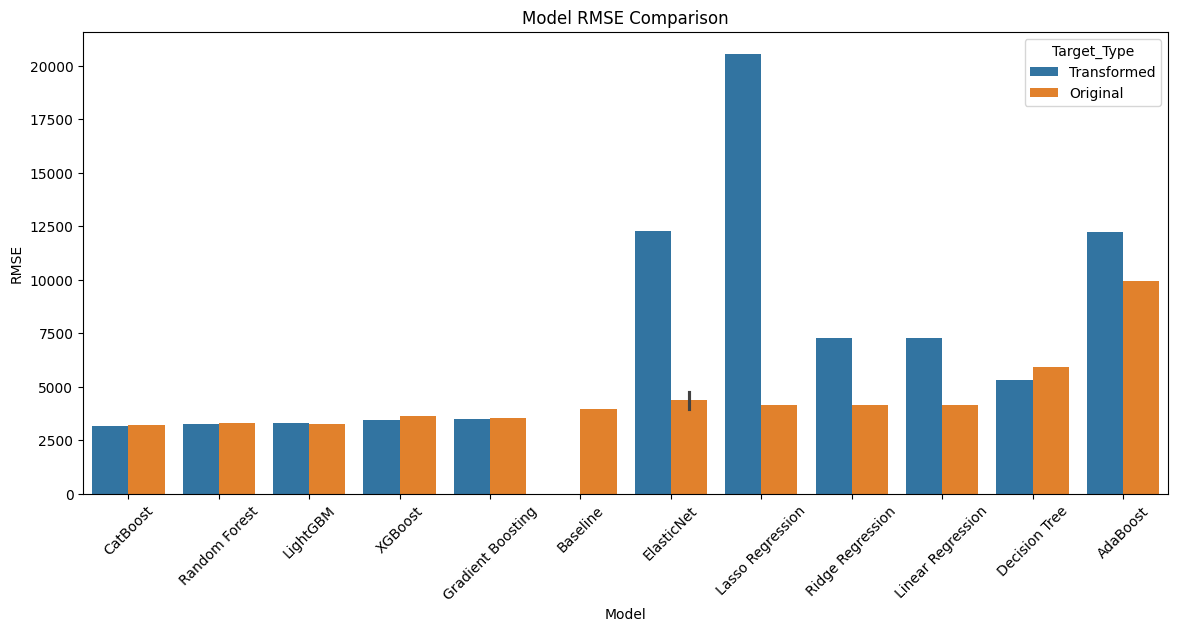

In [ ]:
# visualize model RMSE comparison
plt.figure(figsize=(14, 6))

sns.barplot(
    data=all_results_df,
    x='Model',
    y='RMSE',
    hue='Target_Type'
)

plt.title('Model RMSE Comparison')
plt.xticks(rotation=45)
plt.savefig('../visuals/RMSE_Comparison.png')
plt.show()

## RMSE Comparison Interpretation

The RMSE chart shows that the boosting models achieved the best forecasting performance overall. CatBoost, Random Forest, and LightGBM produced the lowest forecasting errors and outperformed the baseline model.

Target transformation improved performance for some ensemble models, especially CatBoost and XGBoost, while it reduced performance for most linear regression models.

Decision Tree and AdaBoost produced the highest forecasting errors, indicating weaker forecasting performance compared to the other ensemble models.


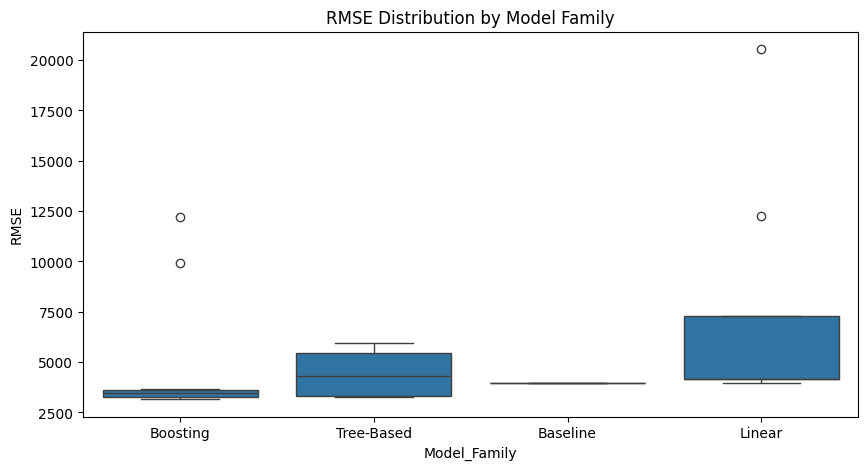

In [ ]:
# visualize RMSE by model family
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=all_results_df,
    x='Model_Family',
    y='RMSE'
)

plt.title('RMSE Distribution by Model Family')
plt.savefig('../visuals/RMSE_Distribution_by_Model_family.png')
plt.show()

## RMSE Distribution by Model Family

The RMSE distribution shows that boosting models achieved the most consistent forecasting performance overall, with lower forecasting errors across most experiments.

Tree-based models also performed strongly, mainly due to the performance of Random Forest, although the single Decision Tree model produced higher forecasting errors.

Linear models showed the widest variation in performance, especially after target transformation, which increased forecasting errors significantly for some models.


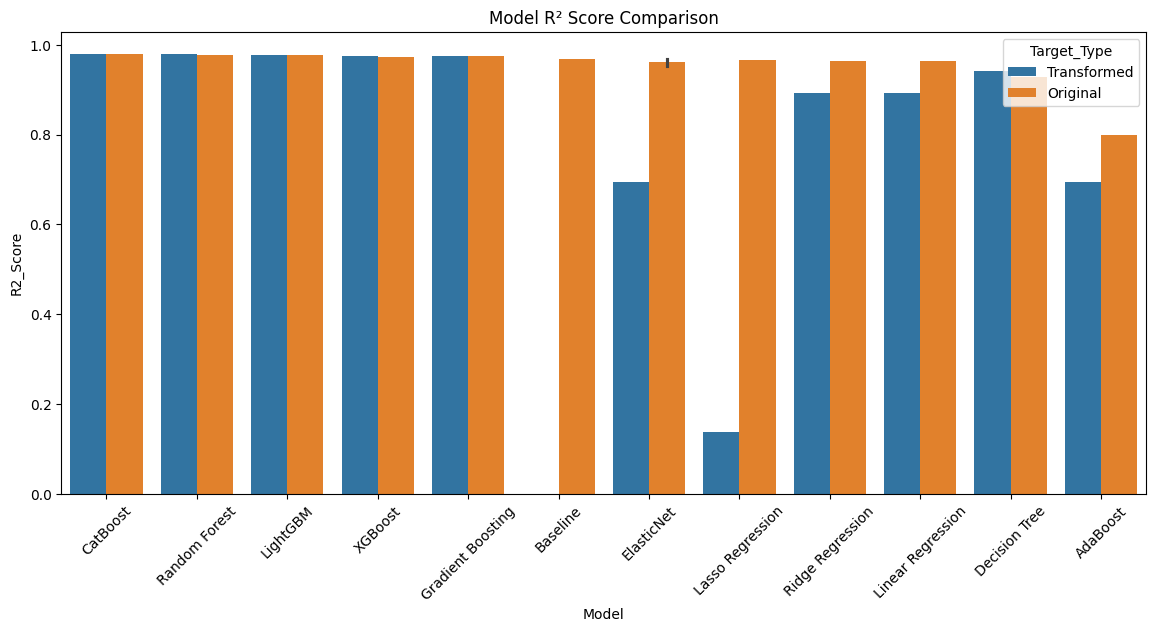

In [ ]:
# visualize R² score comparison
plt.figure(figsize=(14, 6))

sns.barplot(
    data=all_results_df,
    x='Model',
    y='R2_Score',
    hue='Target_Type'
)

plt.title('Model R² Score Comparison')
plt.xticks(rotation=45)
plt.savefig('../visuals/R2_score_Comparison.png')

plt.show()

## R² Score Comparison Interpretation

The R² comparison shows that the ensemble models achieved the strongest forecasting performance overall, with CatBoost, Random Forest, LightGBM, and XGBoost producing the highest R² scores.

The transformed target variable improved performance for some ensemble models, particularly CatBoost and XGBoost, while it reduced performance significantly for several linear regression models.

The chart also shows that the baseline model remained highly competitive, confirming that previous sales values contain strong predictive information within the dataset.


## Hyperparameter Tuning

In this section, the top-performing forecasting models will be optimized using hyperparameter tuning.

The objective is to improve forecasting accuracy by searching for better model configurations beyond the default parameter settings.

RandomizedSearchCV will be used for tuning because it provides an efficient balance between model optimization and computational cost.

The tuning process will begin with CatBoost, which achieved the strongest forecasting performance during the previous model experiments.


In [ ]:
# sort models by RMSE
sorted_results = all_results_df.sort_values( by='RMSE')

# keep best experiment for each model
best_models_df = sorted_results.drop_duplicates(subset='Model')

# select top 3 unique models
top_3_models = best_models_df.head(3)

top_3_models

,Model,Feature_Type,Target_Type,MAE,RMSE,R2_Score,Model_Family
26,CatBoost,Unscaled,Transformed,1469.164350,3164.261642,0.979563,Boosting
15,Random Forest,Unscaled,Transformed,1530.035392,3256.624243,0.978353,Tree-Based
20,LightGBM,Unscaled,Original,1513.247293,3282.181994,0.978012,Boosting


In [ ]:
# function to tune and evaluate forecasting models
def tune_model(

    model,
    param_grid,

    X_train,
    y_train,

    X_test,
    y_test,

    model_name,

    feature_type,
    target_type,

    inverse_transformer=None,

    n_iter=10,
    cv=3
):
    """
    Perform hyperparameter tuning using RandomizedSearchCV,
    evaluate tuned model performance,
    and return results.
    """

    # initialize randomized search
    random_search = RandomizedSearchCV(

        estimator=model,

        param_distributions=param_grid,

        n_iter=n_iter,

        scoring='neg_root_mean_squared_error',

        cv=cv,

        random_state=42,

        n_jobs=2,

        verbose=0
    )

    # fit randomized search
    random_search.fit(
        X_train,
        y_train
    )

    # extract best model
    best_model = random_search.best_estimator_

    # generate predictions
    predictions = best_model.predict(
        X_test
    )

    # inverse transform if needed
    if inverse_transformer is not None:

        predictions = inverse_transformer.inverse_transform(

            predictions.reshape(-1, 1)
        ).flatten()

        y_actual = inverse_transformer.inverse_transform(

            y_test.values.reshape(-1, 1)
        ).flatten()

    else:
        y_actual = y_test

    # calculate metrics
    mae = mean_absolute_error(
        y_actual,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_actual,
            predictions
        )
    )

    r2 = r2_score(
        y_actual,
        predictions
    )

    # store tuning results
    results = {

        'Model': model_name,

        'Feature_Type': feature_type,

        'Target_Type': target_type,

        'MAE': mae,

        'RMSE': rmse,

        'R2_Score': r2,

        'Best_Params': random_search.best_params_
    }

    return best_model, results

In [ ]:
# catboost parameter grid
catboost_params = {
    'depth': [4, 6, 8],

    'learning_rate': [0.01, 0.05, 0.1],

    'iterations': [200, 500],

    'l2_leaf_reg': [1, 3, 5]
}


# lightgbm parameter grid
lightgbm_params = {

    'num_leaves': [31, 50, 100],

    'learning_rate': [0.01, 0.05, 0.1],

    'n_estimators': [200, 500],

    'max_depth': [-1, 10, 20]
}

In [ ]:
#  tune catboost model
best_catboost, tuned_catboost_result = tune_model(
    model=CatBoostRegressor(random_state=42),

    param_grid=catboost_params,

    X_train=X_train,
    X_test=X_test,

    y_train=y_train_log,
    y_test=y_test_log,

    feature_type='Unscaled',
    target_type='Transformed',

    inverse_transformer=power_transformer,
    model_name='CatBoost'
)

0:	learn: 0.9707431	total: 141ms	remaining: 28s
1:	learn: 0.9317481	total: 182ms	remaining: 18s
2:	learn: 0.8948845	total: 223ms	remaining: 14.7s
3:	learn: 0.8601389	total: 265ms	remaining: 13s
4:	learn: 0.8278240	total: 300ms	remaining: 11.7s
5:	learn: 0.7968318	total: 335ms	remaining: 10.8s
6:	learn: 0.7675886	total: 383ms	remaining: 10.6s
7:	learn: 0.7401052	total: 418ms	remaining: 10s
8:	learn: 0.7143485	total: 468ms	remaining: 9.92s
0:	learn: 0.9569032	total: 127ms	remaining: 25.2s
9:	learn: 0.6900696	total: 523ms	remaining: 9.93s
1:	learn: 0.9164834	total: 174ms	remaining: 17.3s
10:	learn: 0.6672881	total: 590ms	remaining: 10.1s
2:	learn: 0.8779330	total: 226ms	remaining: 14.9s
11:	learn: 0.6460761	total: 646ms	remaining: 10.1s
3:	learn: 0.8417017	total: 292ms	remaining: 14.3s
4:	learn: 0.8083343	total: 347ms	remaining: 13.5s
12:	learn: 0.6260568	total: 720ms	remaining: 10.4s
5:	learn: 0.7758114	total: 403ms	remaining: 13s
13:	learn: 0.6073694	total: 777ms	remaining: 10.3s
14:	le

In [ ]:
# tune LightGBM model
best_lightgbm_model, tuned_lightgbm_result = tune_model(
    model=LGBMRegressor(random_state=42),

    param_grid=lightgbm_params,

    X_train=X_train,
    X_test=X_test,

    y_train=y_train,
    y_test=y_test,

    feature_type="Unscaled",
    target_type="Original",

    inverse_transformer=None,
    model_name='LightGBM'
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.058888 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3505
[LightGBM] [Info] Number of data points in the train set: 178992, number of used features: 27
[LightGBM] [Info] Start training from score 16251.136750
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027748 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3500
[LightGBM] [Info] Number of data points in the train set: 178992, number of used features: 27
[LightGBM] [Info] Start training from score 16428.552798
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.115682 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] T

In [ ]:
# combine tuned model results
tuned_results = [tuned_catboost_result, tuned_lightgbm_result]

#tuned model comparison dataframe
tuned_results_df = pd.DataFrame(tuned_results)

# sort by RMSE
tuned_results_df.sort_values(by='RMSE')

,Model,Feature_Type,Target_Type,MAE,RMSE,R2_Score,Best_Params
1,LightGBM,Unscaled,Original,1473.296890,3098.218415,0.980408,"{'num_leaves': 50, 'n_estimators': 500, 'max_d..."
0,CatBoost,Unscaled,Transformed,1578.536444,3607.868066,0.973432,"{'learning_rate': 0.01, 'l2_leaf_reg': 3, 'ite..."


## Tuned Model Results and Observations

Hyperparameter tuning improved the performance of the top forecasting models, particularly LightGBM.

After tuning, LightGBM achieved the best overall forecasting performance with:

* RMSE: 3098.22
* MAE: 1473.30
* R² Score: 0.9804

This result outperformed:

* the baseline forecasting model
* all untuned models
* the tuned CatBoost model

The tuning process improved LightGBM’s ability to capture complex nonlinear relationships and temporal forecasting patterns within the retail sales data.

Although CatBoost remained a strong forecasting model after tuning, LightGBM produced lower forecasting errors and slightly higher explanatory power, making it the final best-performing machine learning model in the project.


## Feature Importance Analysis

In this section, feature importance analysis will be performed using the best-performing forecasting model.

The objective is to identify the variables that contributed most to retail sales forecasting performance.

Understanding feature importance helps explain:

* the strongest sales drivers
* the impact of historical sales patterns
* the influence of seasonal factors
* the contribution of markdown and economic variables

The analysis will be conducted using the tuned LightGBM model, which achieved the best overall forecasting performance after hyperparameter tuning.


In [ ]:
# extract feature importance
feature_importance = pd.DataFrame({
    'Features': X_train.columns,
    'Importance': best_lightgbm_model.feature_importances_
})

# Top 10 feature importance
top_10_features = feature_importance.sort_values(by='Importance', ascending=False).head(10)

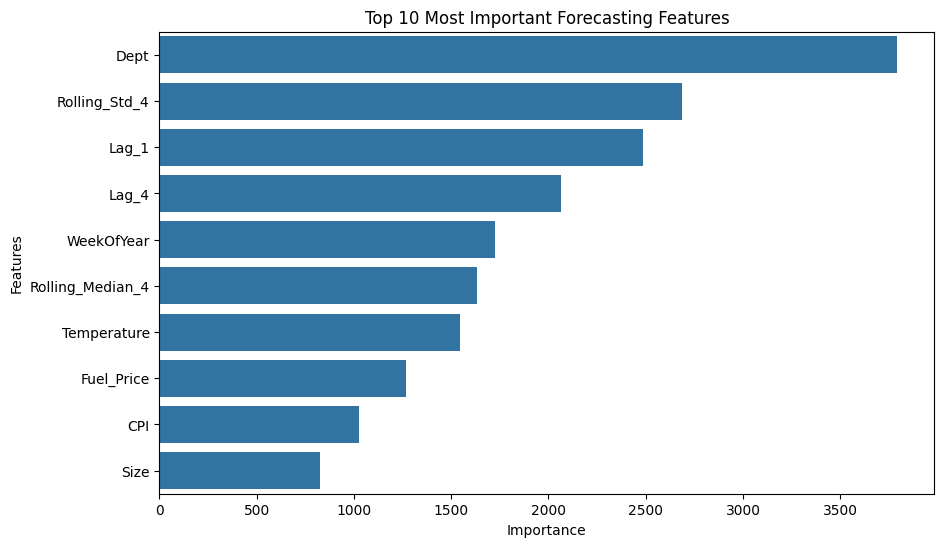

In [ ]:
# visualize top 10 important features
plt.figure(figsize=(10, 6))

sns.barplot(

    data=top_10_features,

    x='Importance',

    y='Features'
)

plt.title('Top 10 Most Important Forecasting Features')
plt.savefig("../visuals/top_10_feature_importance.png")

plt.show()

## Feature Importance Results and Interpretation

The feature importance analysis shows that department information was the most influential variable in forecasting weekly retail sales. This suggests that sales behavior varies significantly across different product departments.

Lag-based and rolling statistical features also ranked among the most important predictors. Features such as Lag_1, Lag_4, Rolling_Std_4, and Rolling_Median_4 contributed strongly to forecasting performance, confirming that historical sales behavior played a major role in predicting future sales.

Seasonal patterns were also important, as shown by the influence of the WeekOfYear feature. This indicates that weekly seasonal trends contributed meaningfully to sales forecasting.

Economic and store-related variables such as Temperature, Fuel Price, CPI, and Store Size also contributed to the model, although their influence was lower compared to the lag and rolling features.

Overall, the feature importance results validate the effectiveness of the feature engineering process and confirm that historical sales patterns, department-level behavior, and seasonal trends were the strongest drivers of forecasting performance.


In [ ]:
# generate predictions
lightgbm_predictions = best_lightgbm_model.predict( X_test)

# actual values
y_test_actual = y_test

# forecast comparison dataframe
forecast_df = pd.DataFrame({

    'Actual': y_test_actual,

    'Predicted': lightgbm_predictions
})

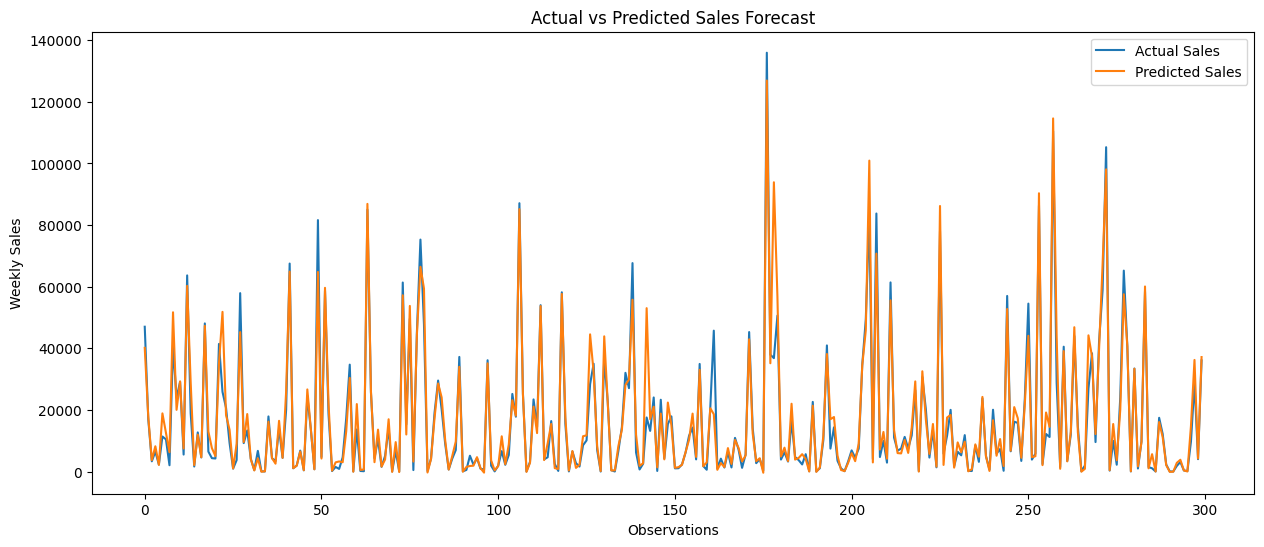

In [ ]:
# visualize actual vs predicted sales
plt.figure(figsize=(15, 6))

plt.plot(
    forecast_df['Actual'].values[:300],
    label='Actual Sales'
)

plt.plot(
    forecast_df['Predicted'].values[:300],
    label='Predicted Sales'
)

plt.title('Actual vs Predicted Sales Forecast')

plt.xlabel('Observations')

plt.ylabel('Weekly Sales')

plt.legend()
plt.savefig("../visuals/actual_vs_predicted_sales_forecast.png")

plt.show()

## Forecast Visualization Interpretation

The forecast plot shows that the tuned LightGBM model was able to follow the actual sales pattern quite well across the test data.

The predicted values closely matched many of the rises, drops, and major sales spikes observed in the actual sales series, showing that the model learned important sales patterns from the historical data.

Although there were a few periods where the model slightly overpredicted or underpredicted sales, the overall forecasting performance remained strong and consistent.

This visualization supports the earlier evaluation metrics and confirms that the tuned LightGBM model performed effectively for retail sales forecasting.


## Prophet Forecasting

In this section, Prophet forecasting will be implemented and compared with the machine learning forecasting models developed earlier in the project.

Unlike the previous machine learning models, Prophet is a specialized time-series forecasting model designed to capture trend, seasonality, and holiday-related patterns within temporal data.

To ensure a fair comparison, external regressors such as economic indicators, markdown variables, and holiday information will also be included in the Prophet model.

The objective of this phase is to evaluate how a dedicated time-series forecasting approach performs relative to the tuned LightGBM forecasting model.


In [ ]:
# importing dataset
sales_df = pd.read_csv(r'/home/emeka/projects/ML_Portfolio/retail-sales-forecasting/data/feature_engineered_sales.csv')
sales_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Type_B,Type_C,Lag_1,Lag_4,Rolling_Median_4,Rolling_Std_4,Month_Sin,Month_Cos,WeekOfYear_Sin,WeekOfYear_Cos
0,1,1,2010-04-02,57258.43,0,62.27,2.719,0.0,0.0,0.0,...,0,0,26229.21,21827.90,21982.270,2325.929203,0.866025,-0.5,1.0,-1.608123e-16
1,36,7,2010-04-02,412.47,0,63.43,2.708,0.0,0.0,0.0,...,0,0,271.91,324.79,320.850,49.535298,0.866025,-0.5,1.0,-1.608123e-16
2,36,8,2010-04-02,3458.71,0,63.43,2.708,0.0,0.0,0.0,...,0,0,3514.53,3420.37,3467.450,361.990914,0.866025,-0.5,1.0,-1.608123e-16
3,7,60,2010-04-02,79.20,0,38.26,2.725,0.0,0.0,0.0,...,1,0,79.20,96.80,96.800,22.146181,0.866025,-0.5,1.0,-1.608123e-16
4,7,59,2010-04-02,245.37,0,38.26,2.725,0.0,0.0,0.0,...,1,0,197.38,190.66,228.075,37.677849,0.866025,-0.5,1.0,-1.608123e-16


In [ ]:
# prophet dataframe
prophet_df = sales_df.copy()

# rename columns for prophet
prophet_df = prophet_df.rename(columns={

    'Date': 'ds',

    'Weekly_Sales': 'y'
})

In [ ]:
prophet_features = [

    'IsHoliday',

    'Temperature',

    'Fuel_Price',

    'CPI',

    'Unemployment',

    'MarkDown1',

    'MarkDown2',

    'MarkDown3',

    'MarkDown4',

    'MarkDown5',

    'Size'
]

In [ ]:
prophet_df = prophet_df.sort_values(by='ds')

# chronological split index
split_index = int(len(prophet_df) * 0.8)

# training data
train_prophet = prophet_df.iloc[:split_index]

# testing data
test_prophet = prophet_df.iloc[split_index:]

In [ ]:
from prophet import Prophet

# initialize prophet
prophet_model = Prophet()

In [ ]:
# add external regressors
for feature in prophet_features:

    prophet_model.add_regressor(feature)

In [ ]:
# fit prophet model
prophet_model.fit( train_prophet[['ds', 'y'] + prophet_features])

# create future dataframe
future = test_prophet[['ds'] + prophet_features]

# generate forecasts
forecast = prophet_model.predict(future)

In [ ]:
# prophet predictions
prophet_predictions = forecast['yhat'].values

# actual values
y_actual = test_prophet['y'].values

In [ ]:
# prophet metrics
prophet_mae = mean_absolute_error(
    y_actual,
    prophet_predictions
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        y_actual,
        prophet_predictions
    )
)

prophet_r2 = r2_score(
    y_actual,
    prophet_predictions
)

# display results
print(f'MAE: {prophet_mae:.2f}')
print(f'RMSE: {prophet_rmse:.2f}')
print(f'R² Score: {prophet_r2:.4f}')